## 0. Crucial imports

In [152]:
import webdataset as wds
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import torch
torch.cuda.is_available()


True

# 1. Data Preparation

### 1.1 Read data to dataframme 
Reading data to pandas dataframe 
Making Dataframe searchable by 'name.png' by changing ID from integers to name of the image

In [153]:
df = pd.read_csv("Data_Entry_2017.csv")
df = df.set_index('Image Index')
print(df.head(3))


                          Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                                     
00000001_000.png            Cardiomegaly            0           1        058Y   
00000001_001.png  Cardiomegaly|Emphysema            1           1        058Y   
00000001_002.png   Cardiomegaly|Effusion            2           1        058Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00000001_000.png              M            PA                 2682     2749   
00000001_001.png              M            PA                 2894     2729   
00000001_002.png              M            PA                 2500     2048   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00000001_000.png                        0.143  0.143          

### 1.2 Encode labels to vector
* Introduce label encoding (not one-hot because of multilabel instances)
* Introduce function returning from vector of 1 and 0 to labels

In [154]:
all_labels = [
    "No Finding", "Atelectasis", "Consolidation", "Infiltration", 
    "Pneumothorax", "Edema", "Emphysema", "Fibrosis", "Effusion", 
    "Pneumonia", "Pleural_Thickening", "Cardiomegaly", "Nodule", "Mass", "Hernia"
]
label_to_idx = {label:i for i, label in enumerate(all_labels)}

def encode_label(label):
    vector_labels = torch.zeros(len(all_labels), dtype=torch.float32)
    
    if not isinstance(label, str): #handling NaN or empty
        return vector_labels
    
    labels = label.split("|")
    for l in labels:
        if l not in label_to_idx:
            continue
        vector_labels[label_to_idx[l]] = 1.0

    return vector_labels

def vector_idx_to_labels(vector_idx):
    return [label for label, val in zip(all_labels, vector_idx) if val > 0.5]

### 1.3 Pipeline for random sample

Taking 1000 images, shuffling them, converting to PyTorchRGB tensors from 12 tar files and returning for it:
* image_data = data of each pixel
* clean_key = name of the photo (without folder name)
* label = name of the disease

In [155]:
def process_sample(sample):

    image_data = sample['png']
    full_key = sample["__key__"]
    clean_key = full_key.replace("images/", "") + ".png"
    vector_label = encode_label(df.at[clean_key, 'Finding Labels'])


    return image_data, clean_key, vector_label


url = "images/images_{001..012}.tar.gz"
dataset = (
    wds.WebDataset(url,shardshuffle=False)
    .shuffle(1000)
    .decode("torchrgb")
    .map(process_sample)
)

for (image, key, vector_label) in dataset:
    print(f"key={key}, image shape={image.shape}, labels={vector_idx_to_labels(vector_label)}")
    break

key=00000376_007.png, image shape=torch.Size([3, 1024, 1024]), labels=['Emphysema', 'Mass']


### 1.4 Displaying three random images from sample

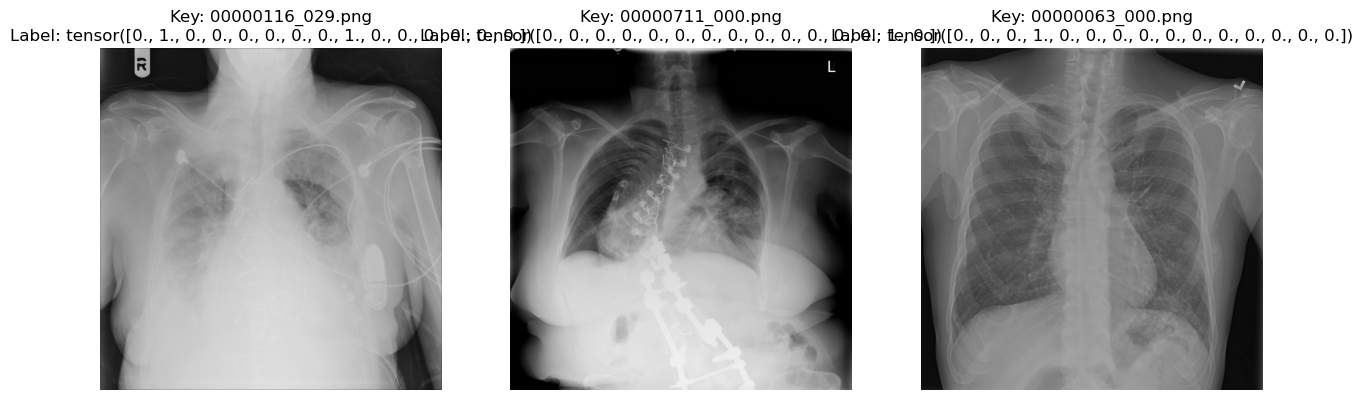

In [156]:

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sample_iter = iter(dataset)

for i in range(3):
    image_tensor, key, label = next(sample_iter)
    img = image_tensor.permute(1, 2, 0).numpy()

    axes[i].imshow(img)
    axes[i].set_title(f"Key: {key}\nLabel: {label[:20]}")
    axes[i].axis('off')

plt.show()

### 1.5 Shuffling csv file for randomness

In [157]:
shuffled_df = df.sample(frac=1)
print(shuffled_df.head(2))

                 Finding Labels  Follow-up #  Patient ID Patient Age  \
Image Index                                                            
00011944_000.png     No Finding            0       11944        055Y   
00027108_006.png    Atelectasis            6       27108        059Y   

                 Patient Gender View Position  OriginalImage[Width  Height]  \
Image Index                                                                   
00011944_000.png              F            PA                 2928     2437   
00027108_006.png              F            AP                 3048     2532   

                  OriginalImagePixelSpacing[x     y]  Unnamed: 11  
Image Index                                                        
00011944_000.png                        0.143  0.143          NaN  
00027108_006.png                        0.139  0.139          NaN  


### 1.6 Splitting data into training and validation

In [158]:
population_size = len(df)
train_split = int(0.8*population_size)

train_df = shuffled_df[:train_split]
val_df = shuffled_df[train_split:]

len(shuffled_df), len(train_df), len(val_df)

(112120, 89696, 22424)